# <span style="color:#E14F20"> Quantitative Comparison of BGFR algorithms // *For MRI QSM* </span> </br>

In [30]:
import os, sys, importlib
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

In [12]:
# Going to load from monkey_tools extract_metric.py
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(parent_dir)
print(parent_dir)

import monkey_tools.extract_metric
importlib.reload(monkey_tools.extract_metric)

from monkey_tools.extract_metric import calculate_rmse # re-import updated function

c:\Users\Admin\Documents\msc_project\Image-processing-strategies


## <span style="color:#9C27B0"> Manual calculation of RMSE </span> </br>

In this section we'll go over loading a GT for RMSE calculation vs several different maps </br>
Useful for debugging!

In [16]:
# Assuming we work at 3Tesla, 
gamma_bar = 42.58 # MHz/T
B0 = 3 # [T]
water_Hz_3T = B0 * gamma_bar # This comes from Larmor equation, gyromagnetic ratio in MHz/T
print("Frequency of water at 3T: ", water_Hz_3T, "MHz")

Frequency of water at 3T:  127.74 MHz


In [4]:
# Load masks for the cropped phantom
gm_msk_crop_data = nib.load(r"E:\msc_data\sc_qsm\final_gauss_sims\masks\sc_gm_crop.nii.gz").get_fdata()
wm_msk_crop_data = nib.load(r"E:\msc_data\sc_qsm\final_gauss_sims\masks\sc_wm_crop.nii.gz").get_fdata()
sc_msk_crop_data = nib.load(r"E:\msc_data\sc_qsm\final_gauss_sims\masks\only_sc_crop.nii.gz").get_fdata()


In [35]:
# Load the GT for BGFR optimization, we are working on debugging PDF
crop_gt_avg_sc_ref_swiss_crop_fm_Hz_data = nib.load(r"E:\msc_data\sc_qsm\final_gauss_sims\feb_2026\gt_data\bgfr_gt_ref_avg_onlySC_fm_Hz_crop.nii.gz").get_fdata()# This loads the Ground truth image with the Swiss Acq. Parameters FOV

pdf_def_tol_50_iters_data = nib.load(r"E:\msc_data\sc_qsm\final_gauss_sims\feb_2026\bgfr_opt\pdf_debug\test2\Sepia_localfield.nii.gz").get_fdata()
pdf_def_tol_100_iters_data = nib.load(r"E:\msc_data\sc_qsm\final_gauss_sims\feb_2026\bgfr_opt\pdf_debug\test9\Sepia_localfield.nii.gz").get_fdata()
pdf_def_tol_250_iters_data = nib.load(r"E:\msc_data\sc_qsm\final_gauss_sims\feb_2026\bgfr_opt\pdf_debug\test8\Sepia_localfield.nii.gz").get_fdata()
pdf_def_tol_500_iters_data = nib.load(r"E:\msc_data\sc_qsm\final_gauss_sims\feb_2026\bgfr_opt\pdf_debug\test10\Sepia_localfield.nii.gz").get_fdata()
pdf_def_tol_1000_iters_data = nib.load(r"E:\msc_data\sc_qsm\final_gauss_sims\feb_2026\bgfr_opt\pdf_debug\test3\Sepia_localfield.nii.gz").get_fdata()
pdf_def_tol_2000_iters_data = nib.load(r"E:\msc_data\sc_qsm\final_gauss_sims\feb_2026\bgfr_opt\pdf_debug\test6\Sepia_localfield.nii.gz").get_fdata()
pdf_def_tol_3000_iters_data = nib.load(r"E:\msc_data\sc_qsm\final_gauss_sims\feb_2026\bgfr_opt\pdf_debug\test7\Sepia_localfield.nii.gz").get_fdata()
pdf_def_tol_4000_iters_data = nib.load(r"E:\msc_data\sc_qsm\final_gauss_sims\feb_2026\bgfr_opt\pdf_debug\test4\Sepia_localfield.nii.gz").get_fdata()
pdf_def_tol_5000_iters_data = nib.load(r"E:\msc_data\sc_qsm\final_gauss_sims\feb_2026\bgfr_opt\pdf_debug\test5\Sepia_localfield.nii.gz").get_fdata()

In [36]:
pdf_def_tol_50_iters_data_no_sd = nib.load(r"E:\msc_data\sc_qsm\final_gauss_sims\feb_2026\bgfr_opt\pdf_debug\test1\Sepia_localfield.nii.gz").get_fdata()
rmse_50_nosd_iters= calculate_rmse(pdf_def_tol_50_iters_data_no_sd, crop_gt_avg_sc_ref_swiss_crop_fm_Hz_data, sc_msk_crop_data, gm_msk_crop_data, wm_msk_crop_data)
print("RMSE for PDF with default tol and 50 iterations, no SD: ", rmse_50_nosd_iters[2])

RMSE for PDF with default tol and 50 iterations, no SD:  1.2627674072049146


In [37]:
# Is there a difference in RMSE between the two?
rmse_50_iters = calculate_rmse(pdf_def_tol_50_iters_data, crop_gt_avg_sc_ref_swiss_crop_fm_Hz_data, sc_msk_crop_data, gm_msk_crop_data, wm_msk_crop_data)
rmse_100_iters = calculate_rmse(pdf_def_tol_100_iters_data, crop_gt_avg_sc_ref_swiss_crop_fm_Hz_data, sc_msk_crop_data, gm_msk_crop_data, wm_msk_crop_data)
rmse_250_iters = calculate_rmse(pdf_def_tol_250_iters_data, crop_gt_avg_sc_ref_swiss_crop_fm_Hz_data, sc_msk_crop_data, gm_msk_crop_data, wm_msk_crop_data)
rmse_500_iters = calculate_rmse(pdf_def_tol_500_iters_data, crop_gt_avg_sc_ref_swiss_crop_fm_Hz_data, sc_msk_crop_data, gm_msk_crop_data, wm_msk_crop_data)
rmse_1000_iters = calculate_rmse(pdf_def_tol_1000_iters_data, crop_gt_avg_sc_ref_swiss_crop_fm_Hz_data, sc_msk_crop_data, gm_msk_crop_data, wm_msk_crop_data)
rmse_2000_iters = calculate_rmse(pdf_def_tol_2000_iters_data, crop_gt_avg_sc_ref_swiss_crop_fm_Hz_data, sc_msk_crop_data, gm_msk_crop_data, wm_msk_crop_data)
rmse_3000_iters = calculate_rmse(pdf_def_tol_3000_iters_data, crop_gt_avg_sc_ref_swiss_crop_fm_Hz_data, sc_msk_crop_data, gm_msk_crop_data, wm_msk_crop_data)
rmse_4000_iters = calculate_rmse(pdf_def_tol_4000_iters_data, crop_gt_avg_sc_ref_swiss_crop_fm_Hz_data, sc_msk_crop_data, gm_msk_crop_data, wm_msk_crop_data)
rmse_5000_iters = calculate_rmse(pdf_def_tol_5000_iters_data, crop_gt_avg_sc_ref_swiss_crop_fm_Hz_data, sc_msk_crop_data, gm_msk_crop_data, wm_msk_crop_data)

In [29]:
print("RMSE for PDF with default tol and 50 iterations: ", rmse_50_iters[2])
print("RMSE for PDF with default tol and 100 iterations: ", rmse_250_iters[2])
print("RMSE for PDF with default tol and 250 iterations: ", rmse_250_iters[2])
print("RMSE for PDF with default tol and 500 iterations: ", rmse_250_iters[2])
print("RMSE for PDF with default tol and 5000 iterations: ", rmse_5000_iters[2])

RMSE for PDF with default tol and 50 iterations:  1.2627674072049146
RMSE for PDF with default tol and 100 iterations:  0.8330340537447982
RMSE for PDF with default tol and 250 iterations:  0.8330340537447982
RMSE for PDF with default tol and 500 iterations:  0.8330340537447982
RMSE for PDF with default tol and 5000 iterations:  1.0103047592549639


In [41]:
print("GM RMSE for PDF with default tol and 50 iterations: ", rmse_50_iters[0])
print("WM RMSE for PDF with default tol and 50 iterations: ", rmse_50_iters[1])
print("The sum of both is NOT the total RMSE", rmse_50_iters[0] + rmse_50_iters[1], " but total RMSE is ", rmse_50_iters[2])

GM RMSE for PDF with default tol and 50 iterations:  1.3007099836054221
WM RMSE for PDF with default tol and 50 iterations:  1.4083248120843193
The sum of both is NOT the total RMSE 2.7090347956897416  but total RMSE is  1.3777198064195686


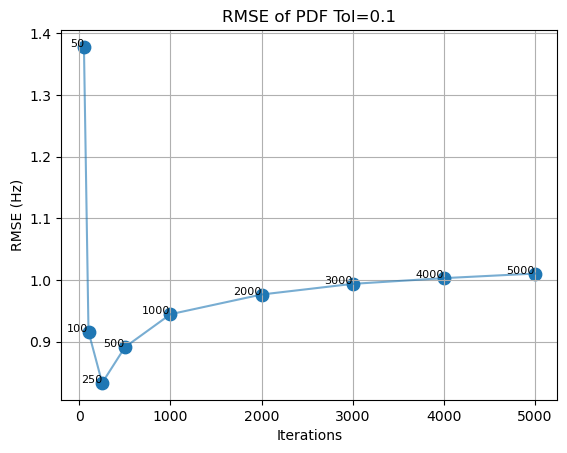

In [38]:
# Now plot RMSE[2] for all iterations to see if there is a trend

iterations = [50, 100, 250, 500,1000, 2000, 3000, 4000, 5000]
rmse_values = [rmse_50_iters[2], rmse_100_iters[2], rmse_250_iters[2], rmse_500_iters[2], rmse_1000_iters[2], rmse_2000_iters[2], rmse_3000_iters[2], rmse_4000_iters[2], rmse_5000_iters[2]]
plt.plot(iterations, rmse_values, linestyle='-', alpha=0.6)
plt.scatter(iterations, rmse_values, s=80)

for x, y in zip(iterations, rmse_values):
    plt.text(x, y, f"{x}", fontsize=8, ha='right')

plt.title('RMSE of PDF Tol=0.1')
plt.xlabel('Iterations')
plt.ylabel('RMSE (Hz)')
plt.grid()
plt.show()

In [15]:
# Calculate percentage increase or decrease in RMSE from x to y 
percent_change = ((rmse_5000_iters[2] - rmse_50_iters[2]) / rmse_50_iters[2]) * 100
print("Percentage change in RMSE from 50 to 5000 iterations: ", percent_change, "%")

Percentage change in RMSE from 50 to 5000 iterations:  -19.992806791613887 %


In [17]:
field_range = crop_gt_avg_sc_ref_swiss_crop_fm_Hz_data[sc_msk_crop_data==1].max() - crop_gt_avg_sc_ref_swiss_crop_fm_Hz_data[sc_msk_crop_data==1].min()
nrmse_50_iters = rmse_50_iters[2] / field_range * 100
print(f'NRMSE: {nrmse_50_iters:.2f}%')

NRMSE: 16.96%


In [16]:
field_range = crop_gt_avg_sc_ref_swiss_crop_fm_Hz_data[sc_msk_crop_data==1].max() - crop_gt_avg_sc_ref_swiss_crop_fm_Hz_data[sc_msk_crop_data==1].min()
nrmse_5000_iters = rmse_5000_iters[2] / field_range * 100
print(f'NRMSE: {nrmse_5000_iters:.2f}%')

NRMSE: 13.57%


### Manual iHARPERELLA

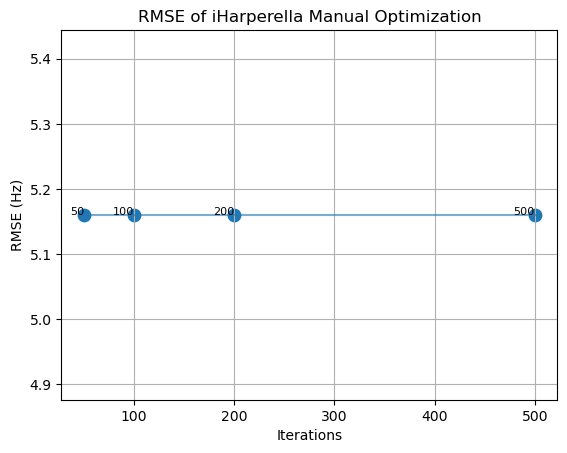

In [42]:
iharperella_100_iters_data = nib.load(r"E:\msc_data\sc_qsm\final_gauss_sims\feb_2026\bgfr_opt\snr_30\manual_iharperella\test1_def\Sepia_localfield.nii.gz").get_fdata()
rmse_iharperella_100_iters = calculate_rmse(iharperella_100_iters_data, crop_gt_avg_sc_ref_swiss_crop_fm_Hz_data, sc_msk_crop_data, gm_msk_crop_data, wm_msk_crop_data)
iharperella_50_iters_data = nib.load(r"E:\msc_data\sc_qsm\final_gauss_sims\feb_2026\bgfr_opt\snr_30\manual_iharperella\test2_50_iters\Sepia_localfield.nii.gz").get_fdata()
rmse_iharperella_50_iters = calculate_rmse(iharperella_50_iters_data, crop_gt_avg_sc_ref_swiss_crop_fm_Hz_data, sc_msk_crop_data, gm_msk_crop_data, wm_msk_crop_data)
iharperella_200_iters_data = nib.load(r"E:\msc_data\sc_qsm\final_gauss_sims\feb_2026\bgfr_opt\snr_30\manual_iharperella\test3_200_iters\Sepia_localfield.nii.gz").get_fdata()
rmse_iharperella_200_iters = calculate_rmse(iharperella_200_iters_data, crop_gt_avg_sc_ref_swiss_crop_fm_Hz_data, sc_msk_crop_data, gm_msk_crop_data, wm_msk_crop_data)
iharperella_500_iters_data = nib.load(r"E:\msc_data\sc_qsm\final_gauss_sims\feb_2026\bgfr_opt\snr_30\manual_iharperella\test4_500_iters\Sepia_localfield.nii.gz").get_fdata()
rmse_iharperella_500_iters = calculate_rmse(iharperella_500_iters_data, crop_gt_avg_sc_ref_swiss_crop_fm_Hz_data, sc_msk_crop_data, gm_msk_crop_data, wm_msk_crop_data)

# Now plot RMSE[2] for all iterations to see if there is a trend for iHarperella's manual optimization
iterations_iharperella = [50, 100, 200, 500]
rmse_values_iharperella = [rmse_iharperella_50_iters[2], rmse_iharperella_100_iters[2], rmse_iharperella_200_iters[2], rmse_iharperella_500_iters[2]]
plt.plot(iterations_iharperella, rmse_values_iharperella, linestyle='-', alpha=0.6)
plt.scatter(iterations_iharperella, rmse_values_iharperella, s=80)
for x, y in zip(iterations_iharperella, rmse_values_iharperella):
    plt.text(x, y, f"{x}", fontsize=8, ha='right')
plt.title('RMSE of iHarperella Manual Optimization')
plt.xlabel('Iterations')
plt.ylabel('RMSE (Hz)')
plt.grid()
plt.show()


In [44]:
# So its the same lmao, let's see the actual RMSE value
print("RMSE for iHARPERELLA with default tol and 50-500 iterations: ", rmse_iharperella_100_iters[2])

RMSE for iHARPERELLA with default tol and 50-500 iterations:  5.160085465733663


# Move this somewhere else later

In [67]:
# Plotting voxels of GM and WM in vivo and comparing with phantom simulations 
# Phase data is unwrapped phase
mag_invivo_data = nib.load(r"E:\msc_data\sc_qsm\neuropoly_data\chi_003\qsm_processing\2nd_3D_meGRE\chi_003_m2_mag.nii.gz").get_fdata()
phs_invivo_img = nib.load(r"E:\msc_data\sc_qsm\neuropoly_data\chi_003\qsm_processing\2nd_3D_meGRE\fm_tests\test3_bipolar_corr\unwrapped.nii")
phs_invivo_data = phs_invivo_img.get_fdata()

mag_phntm_data = nib.load(r"E:\msc_data\sc_qsm\final_gauss_sims\November_2025\mrsim_outputs\custom_params_snr_30\gauss_crop_sim_mag_pro.nii.gz").get_fdata()
phs_phntm_img = nib.load(r"E:\msc_data\sc_qsm\final_gauss_sims\November_2025\mrsim_outputs\custom_params_snr_30\fm_tests\test2_msk_apply\unwrapped.nii")
phs_phntm_data = phs_phntm_img.get_fdata()

In [52]:
# Now load wm and gm points to show evolution through echoes and compare between in vivo and phantom
wm_phntm_vox_data = nib.load(r"E:\msc_data\sc_qsm\final_gauss_sims\masks\sc_wm_crop.nii.gz").get_fdata()
gm_phntm_vox_data = nib.load(r"E:\msc_data\sc_qsm\final_gauss_sims\masks\sc_gm_crop.nii.gz").get_fdata()

wm_invivo_vox_data = nib.load(r"E:\msc_data\sc_qsm\neuropoly_data\chi_003\qsm_processing\2nd_3D_meGRE\chi_003_m2_wm_msk.nii.gz").get_fdata()
gm_invivo_vox_data = nib.load(r"E:\msc_data\sc_qsm\neuropoly_data\chi_003\qsm_processing\2nd_3D_meGRE\chi_003_m2_gm_msk.nii.gz").get_fdata()

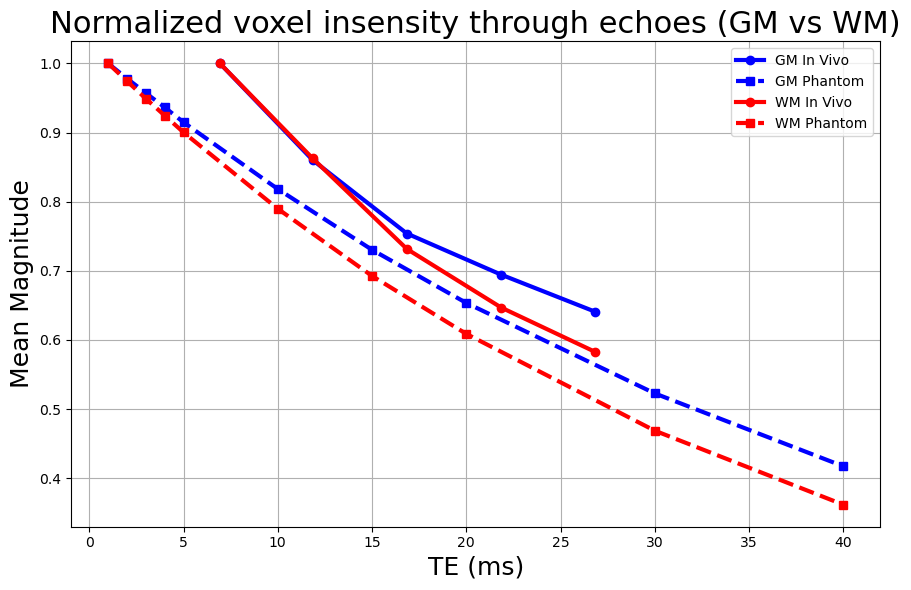

In [66]:
# Now, we know that in vivo the TEs are [6.93, 11.85, 16.85, 21.85, 26.85]
# And in the phantom its [1, 2, 3, 4, 5, 10, 15, 20, 30, 40]

# So lets plot the evolution of voxel intensitiy in magnitude and phase through echoes

tes_invivo = np.array([6.93, 11.85, 16.85, 21.85, 26.85])
tes_phntm  = np.array([1, 2, 3, 4, 5, 10, 15, 20, 30, 40])

# Masks
gm_invivo_mask = gm_invivo_vox_data > 0
wm_invivo_mask = wm_invivo_vox_data > 0
gm_phntm_mask  = gm_phntm_vox_data > 0
wm_phntm_mask  = wm_phntm_vox_data > 0

# Extract voxel values (N_voxels x N_echoes)
gm_invivo_vals = mag_invivo_data[gm_invivo_mask, :]
wm_invivo_vals = mag_invivo_data[wm_invivo_mask, :]
gm_phntm_vals  = mag_phntm_data[gm_phntm_mask, :]
wm_phntm_vals  = mag_phntm_data[wm_phntm_mask, :]

# Mean across voxels
gm_invivo_mean = gm_invivo_vals.mean(axis=0)
wm_invivo_mean = wm_invivo_vals.mean(axis=0)
gm_phntm_mean  = gm_phntm_vals.mean(axis=0)
wm_phntm_mean  = wm_phntm_vals.mean(axis=0)

gm_invivo_mean /= gm_invivo_mean[0]
wm_invivo_mean /= wm_invivo_mean[0]
gm_phntm_mean  /= gm_phntm_mean[0]
wm_phntm_mean  /= wm_phntm_mean[0]

# ----------- PLOT -----------
plt.figure(figsize=(9, 6))

# GM = blue
plt.plot(tes_invivo, gm_invivo_mean, color='blue', linestyle='-', marker='o', linewidth=3, label='GM In Vivo')
plt.plot(tes_phntm,  gm_phntm_mean,  color='blue', linestyle='--', marker='s', linewidth=3, label='GM Phantom')

# WM = red
plt.plot(tes_invivo, wm_invivo_mean, color='red', linestyle='-', marker='o', linewidth=3, label='WM In Vivo')
plt.plot(tes_phntm,  wm_phntm_mean,  color='red', linestyle='--', marker='s', linewidth=3, label='WM Phantom')

plt.xlabel('TE (ms)', fontsize=18)
plt.ylabel('Mean Magnitude', fontsize=18)
plt.title('Normalized voxel insensity through echoes (GM vs WM)', fontsize=22)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


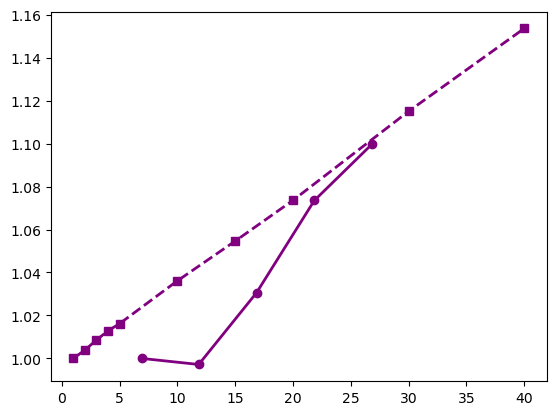

In [56]:
gm_wm_ratio_invivo = gm_invivo_mean / wm_invivo_mean
gm_wm_ratio_phntm  = gm_phntm_mean / wm_phntm_mean

plt.plot(tes_invivo, gm_wm_ratio_invivo, color='purple', linestyle='-', marker='o', linewidth=2, label='GM/WM Ratio In Vivo') 
plt.plot(tes_phntm,  gm_wm_ratio_phntm,  color='purple', linestyle='--', marker='s', linewidth=2, label='GM/WM Ratio Phantom')

In [57]:
from scipy.optimize import curve_fit

def exp_decay(te, S0, T2s):
    return S0 * np.exp(-te / T2s)

def fit_T2star(te, signal):
    popt, _ = curve_fit(exp_decay, te, signal, p0=(1, 30))
    return popt  # S0, T2*

# Fit
S0_gm_invivo, T2s_gm_invivo = fit_T2star(tes_invivo, gm_invivo_mean)
S0_wm_invivo, T2s_wm_invivo = fit_T2star(tes_invivo, wm_invivo_mean)

S0_gm_phntm, T2s_gm_phntm = fit_T2star(tes_phntm, gm_phntm_mean)
S0_wm_phntm, T2s_wm_phntm = fit_T2star(tes_phntm, wm_phntm_mean)

print("GM T2* In Vivo:", T2s_gm_invivo)
print("GM T2* Phantom:", T2s_gm_phntm)
print("WM T2* In Vivo:", T2s_wm_invivo)
print("WM T2* Phantom:", T2s_wm_phntm)

GM T2* In Vivo: 43.40161685879794
GM T2* Phantom: 44.616012746240266
WM T2* In Vivo: 35.523171926798554
WM T2* Phantom: 38.28893389412359


In [60]:
from scipy.interpolate import interp1d

f = interp1d(tes_phntm, gm_phntm_mean, kind='linear')
gm_phntm_interp = f(tes_invivo)

rmse_gm = np.sqrt(np.mean((gm_invivo_mean - gm_phntm_interp)**2))
print("RMSE between in vivo GM and interpolated phantom GM: ", rmse_gm)

# Now for wm
f_wm = interp1d(tes_phntm, wm_phntm_mean, kind='linear')
wm_phntm_interp = f_wm(tes_invivo)  
rmse_wm = np.sqrt(np.mean((wm_invivo_mean - wm_phntm_interp)**2))
print("RMSE between in vivo WM and interpolated phantom WM: ", rmse_wm)


RMSE between in vivo GM and interpolated phantom GM:  0.08169813923476825
RMSE between in vivo WM and interpolated phantom WM:  0.09589067804232373


In [61]:
corr_gm = np.corrcoef(gm_invivo_mean, gm_phntm_interp)[0,1]
print("Correlation coefficient between in vivo GM and interpolated phantom GM: ", corr_gm)
corr_wm = np.corrcoef(wm_invivo_mean, wm_phntm_interp)[0,1]
print("Correlation coefficient between in vivo WM and interpolated phantom WM: ", corr_wm)

Correlation coefficient between in vivo GM and interpolated phantom GM:  0.989937474837495
Correlation coefficient between in vivo WM and interpolated phantom WM:  0.9969085183605535


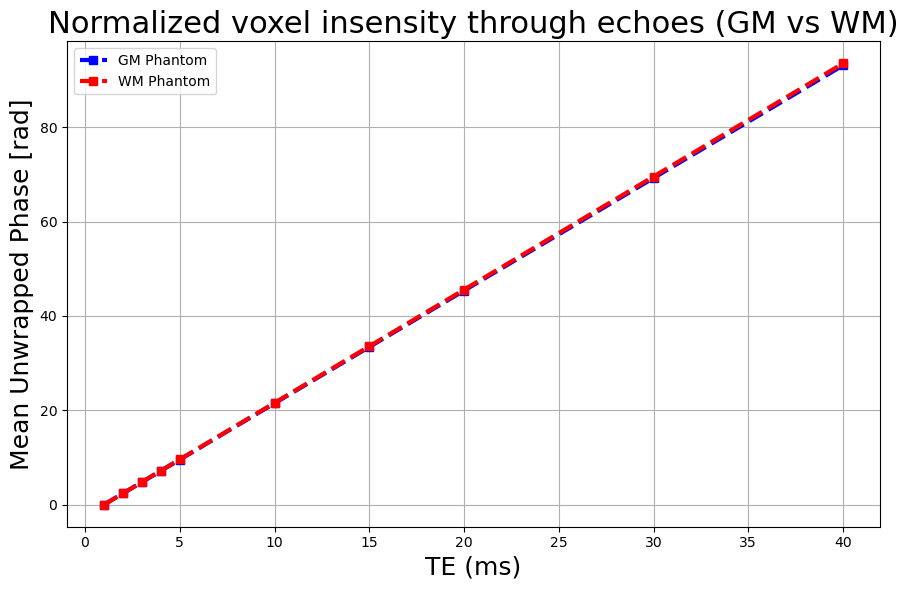

In [80]:
# Now for phase values


# Extract voxel values (N_voxels x N_echoes)
gm_invivo_vals = phs_invivo_data[gm_invivo_mask, :]
wm_invivo_vals = phs_invivo_data[wm_invivo_mask, :]
gm_phntm_vals  = phs_phntm_data[gm_phntm_mask, :]
wm_phntm_vals  = phs_phntm_data[wm_phntm_mask, :]


# 2. remove phase offset (CRITICAL)
gm_invivo_vals -= gm_invivo_vals[:, [0]]
wm_invivo_vals -= wm_invivo_vals[:, [0]]
gm_phntm_vals  -= gm_phntm_vals[:, [0]]
wm_phntm_vals  -= wm_phntm_vals[:, [0]]

# 3. average
gm_invivo_mean = gm_invivo_vals.mean(axis=0)
wm_invivo_mean = wm_invivo_vals.mean(axis=0)
gm_phntm_mean  = gm_phntm_vals.mean(axis=0)
wm_phntm_mean  = wm_phntm_vals.mean(axis=0)

# 4. optional: fix sign mismatch
gm_phntm_mean *= -1
wm_phntm_mean *= -1

# ----------- PLOT -----------
plt.figure(figsize=(9, 6))

# GM = blue
#plt.plot(tes_invivo, gm_invivo_mean, color='blue', linestyle='-', marker='o', linewidth=3, label='GM In Vivo')
plt.plot(tes_phntm,  gm_phntm_mean,  color='blue', linestyle='--', marker='s', linewidth=3, label='GM Phantom')

# WM = red
#plt.plot(tes_invivo, wm_invivo_mean, color='red', linestyle='-', marker='o', linewidth=3, label='WM In Vivo')
plt.plot(tes_phntm,  wm_phntm_mean,  color='red', linestyle='--', marker='s', linewidth=3, label='WM Phantom')

plt.xlabel('TE (ms)', fontsize=18)
plt.ylabel('Mean Unwrapped Phase [rad]', fontsize=18)
plt.title('Normalized voxel insensity through echoes (GM vs WM)', fontsize=22)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

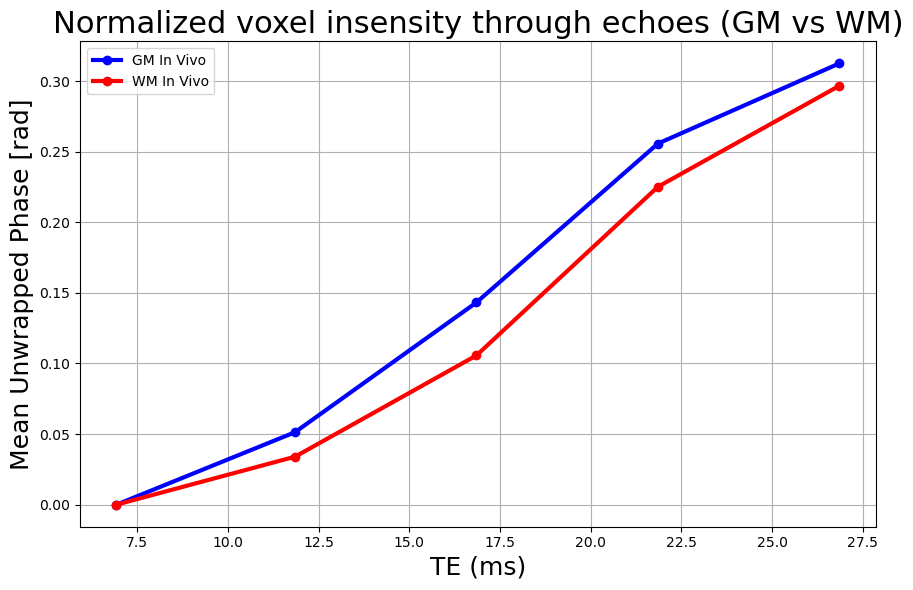

In [78]:
plt.figure(figsize=(9, 6))

# GM = blue
plt.plot(tes_invivo, gm_invivo_mean, color='blue', linestyle='-', marker='o', linewidth=3, label='GM In Vivo')
#plt.plot(tes_phntm,  gm_phntm_mean,  color='blue', linestyle='--', marker='s', linewidth=3, label='GM Phantom')

# WM = red
plt.plot(tes_invivo, wm_invivo_mean, color='red', linestyle='-', marker='o', linewidth=3, label='WM In Vivo')
#plt.plot(tes_phntm,  wm_phntm_mean,  color='red', linestyle='--', marker='s', linewidth=3, label='WM Phantom')

plt.xlabel('TE (ms)', fontsize=18)
plt.ylabel('Mean Unwrapped Phase [rad]', fontsize=18)
plt.title('Normalized voxel insensity through echoes (GM vs WM)', fontsize=22)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()